# Transfer Learning for Biomedical Imaging
Tunneling Nanotubes (TNT) Detection in Cancer Cells

# Introduction

## Information About the Project

### Objective
The primary objective of this project is to apply transfer learning to detect tunneling nanotubes (TNTs) in fluorescence microscopy images of cancer cells. This is a binary patch classification task, where the model predicts whether a given image patch contains a TNT or not.

### Scope
The scope of the project focuses on building a complete, working end-to-end pipeline rather than achieving the highest possible accuracy. Key steps include:

* Extracting labeled image patches from a pair of provided large images.

* Building a custom dataset for binary classification.  

* Applying a transfer learning model (such as VGG16) to the data.  

* Training models on two different patch sizes (512 px and 256 px) and comparing their performance.

* Implementing checkpointing and evaluating a three-phase training schedule.

## Description of the Dataset

* Source: The data consists of fluorescence microscopy images. These images are captured from cancer cells that have been grown on a glass slide, labeled with fluorescent markers, and scanned using a fluorescence microscope. The dataset structure contains exactly two identical large images: original.png (the clean image) and annotated.png (the image with TNTs manually marked by yellow lines).

* Size: The original files are very large images comprising thousands of pixels per dimension. From these, the dataset will be generated by extracting smaller overlapping or non-overlapping patches, specifically sized at 512x512 pixels and 256x256 pixels.

* Type: This is image data (microscopy images).  

## Description of the Columns

* Target Variable: The target is a discrete binary label indicating the presence of a tunneling nanotube. The label is assigned as 1 if the patch contains a TNT (determined by the presence of yellow lines in the corresponding patch of the annotated image) and 0 if it contains no TNT. The dataset features a class imbalance, as most patches contain no TNTs.

* Feature Variables: The features are the image patches extracted exclusively from the original.png clean image. These features take the form of image pixel arrays (either 512x512 or 256x256 pixels)

# Task 1: Setup and Patch Creation

## Step 1.1: Import Libraries and Set Seeds

In [29]:
import os
import time
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, Subset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import copy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
seed = 42
set_seed(seed)

# Configure device for GPU/CPU use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Step 1.2: (Optional) Shadow Removal

## Step 1.3: Patch Extraction

In [30]:
def setup_output_directories(output_dir):
    """
    Creates output directories for classes and returns their paths.
    """
    tnt_dir = os.path.join(output_dir, 'tnt')
    no_tnt_dir = os.path.join(output_dir, 'no_tnt')
    
    os.makedirs(tnt_dir, exist_ok=True)
    os.makedirs(no_tnt_dir, exist_ok=True)
    
    return tnt_dir, no_tnt_dir

In [31]:
def get_sliding_window_coords(height, width, patch_size, stride):
    """
    Generates a list of (x, y) coordinates for the sliding window.
    """
    coords = []
    for y in range(0, height - patch_size + 1, stride):
        for x in range(0, width - patch_size + 1, stride):
            coords.append((x, y))
    return coords

In [32]:
def contains_full_annotation(patch, lower_color, upper_color):
    """
    Returns True ONLY if the patch contains the yellow annotation AND 
    the annotation does not touch any of the patch's borders (not cut off).
    """
    hsv_patch = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_patch, lower_color, upper_color)
    
    # If there are no yellow pixels at all, return False
    if cv2.countNonZero(mask) == 0:
        return False
        
    # Check the 1-pixel outer perimeter of the patch
    touches_top    = np.any(mask[0, :] > 0)
    touches_bottom = np.any(mask[-1, :] > 0)
    touches_left   = np.any(mask[:, 0] > 0)
    touches_right  = np.any(mask[:, -1] > 0)
    
    # If yellow touches any border, the line was cut off -> return False
    if touches_top or touches_bottom or touches_left or touches_right:
        return False
        
    return True

In [33]:
def save_sample_previews(original_img, annotated_img, tnt_coords, patch_size, output_dir, num_samples=3):
    """
    Selects random TNT patch coordinates and saves side-by-side original & annotated previews.
    """
    if not tnt_coords:
        print("  No TNT patches found to generate preview samples.")
        return

    sample_dir = os.path.join(output_dir, 'samples')
    os.makedirs(sample_dir, exist_ok=True)

    # Pick up to num_samples random TNT coordinates
    selected_coords = random.sample(tnt_coords, min(num_samples, len(tnt_coords)))

    for i, (x, y) in enumerate(selected_coords, 1):
        orig_patch = original_img[y:y+patch_size, x:x+patch_size]
        ann_patch = annotated_img[y:y+patch_size, x:x+patch_size]

        # Combine Original patch (left) and Annotated patch (right) side-by-side
        comparison_img = np.hstack((orig_patch, ann_patch))

        save_path = os.path.join(sample_dir, f"tnt_sample_{i}_comparison.png")
        cv2.imwrite(save_path, comparison_img)

    print(f"  Saved {len(selected_coords)} TNT sample previews to: {sample_dir}")

In [34]:
def extract_patches(original_path, annotated_path, patch_size, stride, output_dir):
    """
    Extracts patches from the original image and sorts them into 'tnt' or 'no_tnt' folders
    based on the presence of yellow TNT annotations in the annotated image.
    """
    
    # Setup
    tnt_dir, no_tnt_dir = setup_output_directories(output_dir)
    original_img = cv2.imread(original_path)
    annotated_img = cv2.imread(annotated_path)

    if original_img is None or annotated_img is None:
        print("Error: Could not load one or both images. Please check the file paths.")
        return

    height, width, _ = original_img.shape
    lower_yellow = np.array([20, 100, 100])
    upper_yellow = np.array([40, 255, 255])

    coords = list(get_sliding_window_coords(height, width, patch_size, stride))

    patch_count = 0
    tnt_count = 0
    tnt_coords = []  # Track TNT patch positions

    # Extract and Process Patches
    for x, y in coords:
        orig_patch = original_img[y:y+patch_size, x:x+patch_size]
        ann_patch = annotated_img[y:y+patch_size, x:x+patch_size]

        is_tnt = contains_full_annotation(ann_patch, lower_yellow, upper_yellow)
        
        if is_tnt:
            save_dir = tnt_dir
            tnt_count += 1
            tnt_coords.append((x, y))  # Record TNT coordinate
        else:
            save_dir = no_tnt_dir
            
        save_path = os.path.join(save_dir, f"patch_{patch_count}.png")
        cv2.imwrite(save_path, orig_patch)
        patch_count += 1

    # Save Random TNT Preview Comparisons
    save_sample_previews(original_img, annotated_img, tnt_coords, patch_size, output_dir, num_samples=5)

    # Report
    no_tnt_count = patch_count - tnt_count
    print(f"Extraction complete for {output_dir}:")
    print(f"  Total patches: {patch_count}")
    print(f"  TNT patches (label 1): {tnt_count}")
    print(f"  No TNT patches (label 0): {no_tnt_count}")

In [35]:
# Define file paths
orig_path = "../../data/tnt/m05.png"
ann_path = "../../data/tnt/m05-label.png"

# Run 1: 512x512 patches with stride 256
print("Processing 512x512 patches...")
extract_patches(
    original_path=orig_path,
    annotated_path=ann_path,
    patch_size=512,
    stride=256,
    output_dir="processed_512"
)

# Run 2: 256x256 patches with stride 128
print("\nProcessing 256x256 patches...")
extract_patches(
    original_path=orig_path,
    annotated_path=ann_path,
    patch_size=256,
    stride=128,
    output_dir="processed_256"
)

Processing 512x512 patches...
  Saved 5 TNT sample previews to: processed_512\samples
Extraction complete for processed_512:
  Total patches: 391
  TNT patches (label 1): 63
  No TNT patches (label 0): 328

Processing 256x256 patches...
  Saved 5 TNT sample previews to: processed_256\samples
Extraction complete for processed_256:
  Total patches: 1680
  TNT patches (label 1): 66
  No TNT patches (label 0): 1614


# Task 2: Custom Dataset and DataLoaders

## Step 2.1: TNTDataset Class

In [35]:
class TNTDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Custom dataset for TNT binary classification.
        
        Args:
            root_dir (str): Path to the processed directory
            transform (callable, optional): Optional transform to be applied on a sample
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Define the label mapping based on the processed subfolder names
        class_mapping = {'no_tnt': 0, 'tnt': 1}

        # Traverse the directories to collect image paths and their corresponding labels
        for class_name, label in class_mapping.items():
            class_dir = os.path.join(root_dir, class_name)
            
            # Skip if the directory doesn't exist yet
            if not os.path.isdir(class_dir):
                print(f"Warning: Directory not found -> {class_dir}")
                continue
                
            for file_name in os.listdir(class_dir):
                # Ensure we only read image files
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_dir, file_name))
                    self.labels.append(label)

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, idx):
        """Generates one sample of data."""
        img_path = self.image_paths[idx]
        
        # Load the image using PIL
        image = Image.open(img_path).convert('RGB')
        
        # Get the corresponding label and convert it to a torch float tensor
        # (BCEWithLogitsLoss expects float labels for binary classification)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        # Apply any ImageNet-normalized transforms or augmentations
        if self.transform:
            image = self.transform(image)

        return image, label

## Step 2.2: Transforms and Splits

In [36]:
# ImageNet normalized transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


# Validation/Test transforms (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


# Helper class to apply transforms to PyTorch Subsets
class TransformSubset(Dataset):
    """
    Wrapper to apply a specific transform to a PyTorch Subset.
    This allows us to use different transforms for train and val/test splits.
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
            return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset.dataset[self.subset.indices[index]]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

def create_dataloaders(root_dir):
    """
    Creates stratified 70/15/15 splits and returns DataLoaders for a given processed directory.
    """
    # Instantiate the base dataset WITHOUT transforms so we can extract PIL images first
    base_dataset = TNTDataset(root_dir=root_dir, transform=None)
    
    # Extract labels to use for stratified splitting
    labels = base_dataset.labels

    # Stratified 70/15/15 Split
    # First split: 70% Train, 30% Temporary (Validation + Test)
    train_idx, temp_idx, train_labels, temp_labels = train_test_split(
        np.arange(len(labels)), 
        labels, 
        test_size=0.30, 
        stratify=labels, 
        random_state=seed
    )

    # Second split: Divide the 30% Temporary equally into 15% Validation and 15% Test
    val_idx, test_idx = train_test_split(
        temp_idx, 
        test_size=0.50, 
        stratify=temp_labels, 
        random_state=seed
    )

    # Create subsets using the indices
    train_subset = Subset(base_dataset, train_idx)
    val_subset = Subset(base_dataset, val_idx)
    test_subset = Subset(base_dataset, test_idx)

    # Wrap the subsets to apply the specific transforms
    train_data = TransformSubset(train_subset, transform=train_transform)
    val_data = TransformSubset(val_subset, transform=val_test_transform)
    test_data = TransformSubset(test_subset, transform=val_test_transform)

    # Create DataLoaders with batch size = 32
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

    print(f"DataLoaders created for {root_dir}:")
    print(f"  Train: {len(train_data)} samples")
    print(f"  Val:   {len(val_data)} samples")
    print(f"  Test:  {len(test_data)} samples")

    return train_loader, val_loader, test_loader

# Execution
if __name__ == "__main__":
    # Create DataLoaders for the 512px dataset
    print("Setting up 512x512 DataLoaders...")
    train_loader_512, val_loader_512, test_loader_512 = create_dataloaders('processed_512')

    # Create DataLoaders for the 256px dataset
    print("\nSetting up 256x256 DataLoaders...")
    train_loader_256, val_loader_256, test_loader_256 = create_dataloaders('processed_256')

Setting up 512x512 DataLoaders...
DataLoaders created for processed_512:
  Train: 273 samples
  Val:   59 samples
  Test:  59 samples

Setting up 256x256 DataLoaders...
DataLoaders created for processed_256:
  Train: 1176 samples
  Val:   252 samples
  Test:  252 samples


# Task 3: Load and Modify Pretrained Model

## Step 3.1: Load a Pretrained Model
U-Net model

In [37]:
# Load U-Net model from PyTorch Hub
original_unet = torch.hub.load('milesial/Pytorch-UNet', 'unet_carvana', pretrained=True)

# Original model structure
print("--- U-Net Architecture ---")
print(original_unet)

# Final layer
print("\n--- Final Layer ---")
final_layer = original_unet.outc
print(final_layer)

Using cache found in C:\Users\Mark/.cache\torch\hub\milesial_Pytorch-UNet_master


--- U-Net Architecture ---
UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kern

In [38]:
'''
class UNetClassifier(nn.Module):
    def __init__(self):
        super(UNetClassifier, self).__init__()
        
        # Load pretrained model
        self.unet = torch.hub.load('milesial/Pytorch-UNet', 'unet_carvana', pretrained=True)
        
        # Step 3.3: Freeze Feature Extractor (Phase 1)
        # Freeze all backbone layers to retain the pretrained weights
        for param in self.unet.parameters():
            param.requires_grad = False
            
        # Step 3.2: Modify for Binary Classification
        # U-Net's penultimate 'up4' block outputs 64 channels. 
        # Pool the (H, W) spatial dimensions down to 1x1.
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))
        
        # Replace the final layer with nn.Linear(in_features, 1)
        self.classifier = nn.Linear(in_features=64, out_features=1)

    def forward(self, x):
        # Extract features through the U-Net up to the 'up4' block 
        # (bypassing the segmentation-specific 1x1 'outc' convolution)
        x1 = self.unet.inc(x)
        x2 = self.unet.down1(x1)
        x3 = self.unet.down2(x2)
        x4 = self.unet.down3(x3)
        x5 = self.unet.down4(x4)
        
        x = self.unet.up1(x5, x4)
        x = self.unet.up2(x, x3)
        x = self.unet.up3(x, x2)
        features = self.unet.up4(x, x1) # Shape: [Batch, 64, H, W]
        
        # Pool spatial features and flatten for the linear layer
        pooled = self.global_pool(features)  # Shape: [Batch, 64, 1, 1]
        flattened = torch.flatten(pooled, 1) # Shape: [Batch, 64]
        
        # Final binary classification prediction
        output = self.classifier(flattened)
        return output
'''

class UNetClassifier(nn.Module):
    def __init__(self):
        super(UNetClassifier, self).__init__()
        
        # Load pretrained model
        self.unet = torch.hub.load('milesial/Pytorch-UNet', 'unet_carvana', pretrained=True)
        
        # Freeze Feature Extractor (Phase 1)
        for param in self.unet.parameters():
            param.requires_grad = False
            
        # Modify for Binary Classification
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))
        
        # Re-anchored to match the true bottleneck depth of 1024
        self.classifier = nn.Linear(in_features=1024, out_features=1)

    def forward(self, x):
        # Pass through the encoder blocks
        x1 = self.unet.inc(x)
        x2 = self.unet.down1(x1)
        x3 = self.unet.down2(x2)
        x4 = self.unet.down3(x3)
        
        # Stop at the bottleneck (bypassing all 'up' blocks)
        features = self.unet.down4(x4) # Shape: [Batch, 1024, H', W']
        
        # Pool spatial features and flatten for the linear layer
        pooled = self.global_pool(features)  # Shape: [Batch, 1024, 1, 1]
        flattened = torch.flatten(pooled, 1) # Shape: [Batch, 1024]
        
        # Final binary classification prediction
        output = self.classifier(flattened)
        return output


# Map model to device
model_512 = UNetClassifier().to(device)
model_256 = UNetClassifier().to(device)

print(f"U-Net Classifier loaded and sent to: {device}")

Using cache found in C:\Users\Mark/.cache\torch\hub\milesial_Pytorch-UNet_master
Using cache found in C:\Users\Mark/.cache\torch\hub\milesial_Pytorch-UNet_master


U-Net Classifier loaded and sent to: cuda


## Step 3.2: Modify for Binary Classification
Done in Step 3.1

## Step 3.3: Freeze Feature Extractor (Phase 1)
Done in Step 3.1

# Task 4: Training Infrastructure

## Step 4.1: Loss, Optimizer, and Checkpoint Functions

In [ ]:
def compute_criterion(output_dir, device):
    """
    Helper function to calculate positive class weight and build
    nn.BCEWithLogitsLoss for a single patch output directory.
    """
    tnt_dir = os.path.join(output_dir, 'tnt')
    no_tnt_dir = os.path.join(output_dir, 'no_tnt')

    # Count Positive (TNT) Patches
    if os.path.exists(tnt_dir):
        num_positive = len([f for f in os.listdir(tnt_dir) if f.lower().endswith(('.png', '.jpg'))])
    else:
        print(f"[Warning] 'tnt' directory not found at: {tnt_dir}")
        return

    # Count Negative (No TNT) Patches
    if os.path.exists(no_tnt_dir):
        num_negative = len([f for f in os.listdir(no_tnt_dir) if f.lower().endswith(('.png', '.jpg'))])
    else:
        print(f"[Warning] 'no_tnt' directory not found at: {no_tnt_dir}")
        return

    # Calculate weight ratio 
    weight_ratio = num_negative / num_positive

    # Convert to PyTorch tensor on specified device
    pos_weight_tensor = torch.tensor([weight_ratio], dtype=torch.float32).to(device)

    # Build criterion
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    return criterion

criterion_512 = compute_criterion('processed_512', device)
criterion_256 = compute_criterion('processed_256', device)

In [ ]:
# Optimizer
# Filter for parameters where requires_grad=True to ensure Adam only tracks active layers
optimizer_512 = optim.Adam(filter(lambda p: p.requires_grad, model_512.parameters()), lr=0.001)
optimizer_256 = optim.Adam(filter(lambda p: p.requires_grad, model_256.parameters()), lr=0.001)

In [ ]:
def save_checkpoint(epoch, model, optimizer, train_loss, val_loss, train_acc, val_acc, history, filepath):
    """
    Saves the complete training state to a file checkpoint.
    """
    # Create checkpoint dictionary 
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'history': history
    }
    
    # Save the dictionary to disk
    torch.save(checkpoint, filepath)
    print(f"Checkpoint saved to '{filepath}' (Epoch {epoch})")

In [ ]:
def load_checkpoint(filepath, model, optimizer=None, device='cpu'):
    """
    Loads a complete training state from a checkpoint file.
    """
    # Load checkpoint 
    checkpoint = torch.load(filepath, map_location=device)
    
    # Restore model state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Restore optimizer state dict (if optimizer is provided)
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    # Get epoch and history
    epoch = checkpoint['epoch']
    history = checkpoint['history']
    
    # loaded information
    print(f"--- Checkpoint Loaded ---")
    print(f"File: {filepath}")
    print(f"Resumed from Epoch: {epoch}")
    print(f"Saved Training Loss: {checkpoint.get('train_loss', 'N/A'):.4f}")
    print(f"Saved Validation Acc: {checkpoint.get('val_acc', 'N/A'):.4f}")
    
    if optimizer is not None:
        print("Optimizer state successfully restored.\n")
    else:
        print("Model state restored (Optimizer state skipped).\n")
        
    # Return epoch and history
    return epoch, history

## Step 4.2: Training and Validation Loops

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Trains the model for one epoch.
    """
    # Train mode
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Loop through batches
    for images, labels in dataloader:
        # Move data to device
        images = images.to(device)
        labels = labels.to(device).float()

        # Zero parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        # Reshape output from [batch_size, 1] to [batch_size]
        outputs = model(images).squeeze(-1)
        loss = criterion(outputs, labels)
        
        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        # Convert logits to probabilities using sigmoid, then threshold at 0.5
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        
        running_loss += loss.item() * images.size(0)
        correct_predictions += (preds == labels).sum().item()
        total_samples += images.size(0)

    # Return average loss and accuracy for the epoch
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

In [ ]:
def validate(model, dataloader, criterion, device):
    """
    Evaluates the model on validation or test data without backpropagation.
    """
    # Evaluation mode
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    # No gradient computation
    with torch.no_grad():
        # Loop through batches
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device).float()
            
            # Forward pass
            outputs = model(images).squeeze(-1)
            loss = criterion(outputs, labels)
            
            # Track loss and accuracy (no backprop)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            
            running_loss += loss.item() * images.size(0)
            correct_predictions += (preds == labels).sum().item()
            total_samples += images.size(0)
            
    # Return average loss and accuracy
    val_loss = running_loss / total_samples
    val_acc = correct_predictions / total_samples
    
    return val_loss, val_acc

# Task 5: Three-Phase Training (per patch size)

## Phase 1 - Frozen Features (5 epochs)

In [ ]:
# Create the checkpoints directory if it doesn't exist
os.makedirs("checkpoints", exist_ok=True)


def train_phase(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, save_path):
    """
    Helper function to run a training phase for a specified number of epochs.
    Evaluates on the validation set and saves the best model checkpoint.
    """
    # Dictionary to keep track of training metrics
    history = {'train_loss': [], 
               'train_acc': [], 
               'val_loss': [], 
               'val_acc': []
               }
    best_val_acc = 0.0
    
    # Store the best weights to load at the end of the phase
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(1, num_epochs + 1):
        print(f"Epoch {epoch}/{num_epochs}")
        print("-" * 15)
        
        # Train and validate using the functions defined in Step 4.2
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Log history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        
        # Save checkpoint if validation accuracy improves
        if val_acc > best_val_acc:
            print(f"Validation accuracy improved from {best_val_acc:.4f} to {val_acc:.4f}. Saving...")
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            
            # Utilize the save_checkpoint function from Step 4.1
            save_checkpoint(
                epoch=epoch, 
                model=model, 
                optimizer=optimizer, 
                train_loss=train_loss, 
                val_loss=val_loss, 
                train_acc=train_acc, 
                val_acc=val_acc, 
                history=history, 
                filepath=save_path
            )
        print()
        
    # Load best weights into the model before returning for the next phase
    model.load_state_dict(best_model_wts)
    return model, optimizer, history


# Train 512 px Model (Phase 1)
print("=== Starting Phase 1: 512px Model (Frozen Features) ===")

model_512, optimizer_512, history_phase1_512 = train_phase(
    model=model_512,
    train_loader=train_loader_512,
    val_loader=val_loader_512,
    criterion=criterion,
    optimizer=optimizer_512,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase1_512.pth"
)


# Train 256 px Model (Phase 1)
print("\n=== Starting Phase 1: 256px Model (Frozen Features) ===")

model_256, optimizer_256, history_phase1_256 = train_phase(
    model=model_256,
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    criterion=criterion,
    optimizer=optimizer_256,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase1_256.pth"
)

=== Starting Phase 1: 512px Model (Frozen Features) ===
Epoch 1/5
---------------
Train Loss: 0.7902 | Train Acc: 0.5348
Val Loss:   1.0164 | Val Acc:   0.6271
Validation accuracy improved from 0.0000 to 0.6271. Saving...
Checkpoint saved to 'checkpoints/best_phase1_512.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 0.6942 | Train Acc: 0.5678
Val Loss:   0.9280 | Val Acc:   0.6271

Epoch 3/5
---------------
Train Loss: 0.7949 | Train Acc: 0.5568
Val Loss:   0.6708 | Val Acc:   0.6441
Validation accuracy improved from 0.6271 to 0.6441. Saving...
Checkpoint saved to 'checkpoints/best_phase1_512.pth' (Epoch 3)

Epoch 4/5
---------------
Train Loss: 0.6713 | Train Acc: 0.6264
Val Loss:   0.7408 | Val Acc:   0.4237

Epoch 5/5
---------------
Train Loss: 0.6774 | Train Acc: 0.5788
Val Loss:   0.6540 | Val Acc:   0.6271


=== Starting Phase 1: 256px Model (Frozen Features) ===
Epoch 1/5
---------------
Train Loss: 0.4285 | Train Acc: 0.8656
Val Loss:   0.3914 | Val Acc:   0.8690
Valida

## Phase 2 - Resume Training (5 epochs)

In [42]:
# Phase 2: Resume Training - 512px Model
print("=== Starting Phase 2: 512px Model (Resume Training) ===")

# Load the best Phase 1 checkpoint (including the optimizer state)
start_epoch_512, loaded_history_512 = load_checkpoint(
    filepath="checkpoints/best_phase1_512.pth",
    model=model_512,
    optimizer=optimizer_512,
    device=device
)

# Continue training for 5 more epochs (Epochs 6-10)
model_512, optimizer_512, history_phase2_512 = train_phase(
    model=model_512,
    train_loader=train_loader_512,
    val_loader=val_loader_512,
    criterion=criterion,
    optimizer=optimizer_512,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase2_512.pth"
)


# Phase 2: Resume Training - 256px Model
print("\n=== Starting Phase 2: 256px Model (Resume Training) ===")

# Load the best Phase 1 checkpoint (including the optimizer state)
start_epoch_256, loaded_history_256 = load_checkpoint(
    filepath="checkpoints/best_phase1_256.pth",
    model=model_256,
    optimizer=optimizer_256,
    device=device
)

# Continue training for 5 more epochs (Epochs 6-10)
model_256, optimizer_256, history_phase2_256 = train_phase(
    model=model_256,
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    criterion=criterion,
    optimizer=optimizer_256,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase2_256.pth"
)

=== Starting Phase 2: 512px Model (Resume Training) ===
--- Checkpoint Loaded ---
File: checkpoints/best_phase1_512.pth
Resumed from Epoch: 3
Saved Training Loss: 0.7949
Saved Validation Acc: 0.6441
Optimizer state successfully restored.

Epoch 1/5
---------------
Train Loss: 0.6763 | Train Acc: 0.6264
Val Loss:   0.7581 | Val Acc:   0.4237
Validation accuracy improved from 0.0000 to 0.4237. Saving...
Checkpoint saved to 'checkpoints/best_phase2_512.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 0.6611 | Train Acc: 0.6117
Val Loss:   0.6409 | Val Acc:   0.6271
Validation accuracy improved from 0.4237 to 0.6271. Saving...
Checkpoint saved to 'checkpoints/best_phase2_512.pth' (Epoch 2)

Epoch 3/5
---------------
Train Loss: 0.6718 | Train Acc: 0.5971
Val Loss:   0.6972 | Val Acc:   0.6271

Epoch 4/5
---------------
Train Loss: 0.7103 | Train Acc: 0.5385
Val Loss:   0.7699 | Val Acc:   0.6271

Epoch 5/5
---------------
Train Loss: 0.7183 | Train Acc: 0.5604
Val Loss:   0.6715 | Val

## Phase 3 - Fine-Tuning (5 epochs)

In [43]:
def unfreeze_and_finetune(model, filepath_load, filepath_save, train_loader, val_loader, device):
    """
    Helper function to load a model, unfreeze its final layers, 
    update the optimizer, and run the fine-tuning phase.
    """
    # Load the best Phase 2 model weights
    # Optimizer state is not loaded because we are changing the learning rate 
    # and the parameters being tracked.
    load_checkpoint(filepath=filepath_load, model=model, device=device)
    
    # Unfreeze the last few blocks
    # In the U-Net architecture, 'up3' and 'up4' are the final feature extraction blocks.
    print("Unfreezing 'up3' and 'up4' blocks for fine-tuning...")
    for param in model.unet.up3.parameters():
        param.requires_grad = True
    for param in model.unet.up4.parameters():
        param.requires_grad = True
        
    # Create a new optimizer for fine-tuning
    # This captures the newly unfrozen parameters and applies the lower learning rate (1e-4).
    optimizer_finetune = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    
    # Train for 5 epochs (Epochs 11-15)
    model_ft, _, history_ft = train_phase(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_finetune,
        device=device,
        num_epochs=5,
        save_path=filepath_save
    )
    
    return model_ft, history_ft


# Phase 3: Fine-Tuning - 512px Model
print("=== Starting Phase 3: 512px Model (Fine-Tuning) ===")
model_512, history_phase3_512 = unfreeze_and_finetune(
    model=model_512,
    filepath_load="checkpoints/best_phase2_512.pth",
    filepath_save="checkpoints/final_best_512.pth",
    train_loader=train_loader_512,
    val_loader=val_loader_512,
    device=device
)


# Phase 3: Fine-Tuning - 256px Model
print("\n=== Starting Phase 3: 256px Model (Fine-Tuning) ===")
model_256, history_phase3_256 = unfreeze_and_finetune(
    model=model_256,
    filepath_load="checkpoints/best_phase2_256.pth",
    filepath_save="checkpoints/final_best_256.pth",
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    device=device
)

=== Starting Phase 3: 512px Model (Fine-Tuning) ===
--- Checkpoint Loaded ---
File: checkpoints/best_phase2_512.pth
Resumed from Epoch: 2
Saved Training Loss: 0.6611
Saved Validation Acc: 0.6271
Model state restored (Optimizer state skipped).

Unfreezing 'up3' and 'up4' blocks for fine-tuning...
Epoch 1/5
---------------
Train Loss: 0.6610 | Train Acc: 0.6300
Val Loss:   0.6392 | Val Acc:   0.6271
Validation accuracy improved from 0.0000 to 0.6271. Saving...
Checkpoint saved to 'checkpoints/final_best_512.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 0.6462 | Train Acc: 0.6484
Val Loss:   0.6328 | Val Acc:   0.6271

Epoch 3/5
---------------
Train Loss: 0.6500 | Train Acc: 0.6447
Val Loss:   0.6362 | Val Acc:   0.6271

Epoch 4/5
---------------
Train Loss: 0.6489 | Train Acc: 0.6484
Val Loss:   0.6314 | Val Acc:   0.6102

Epoch 5/5
---------------
Train Loss: 0.6558 | Train Acc: 0.6154
Val Loss:   0.6359 | Val Acc:   0.6271


=== Starting Phase 3: 256px Model (Fine-Tuning) ===


# Task 6: Evaluation and Visualization

## Step 6.1: Comprehensive Plots

=== Generating Plots for 512px Model ===
Figure saved successfully as 'images/training_history_model_512px.png' with DPI=300.


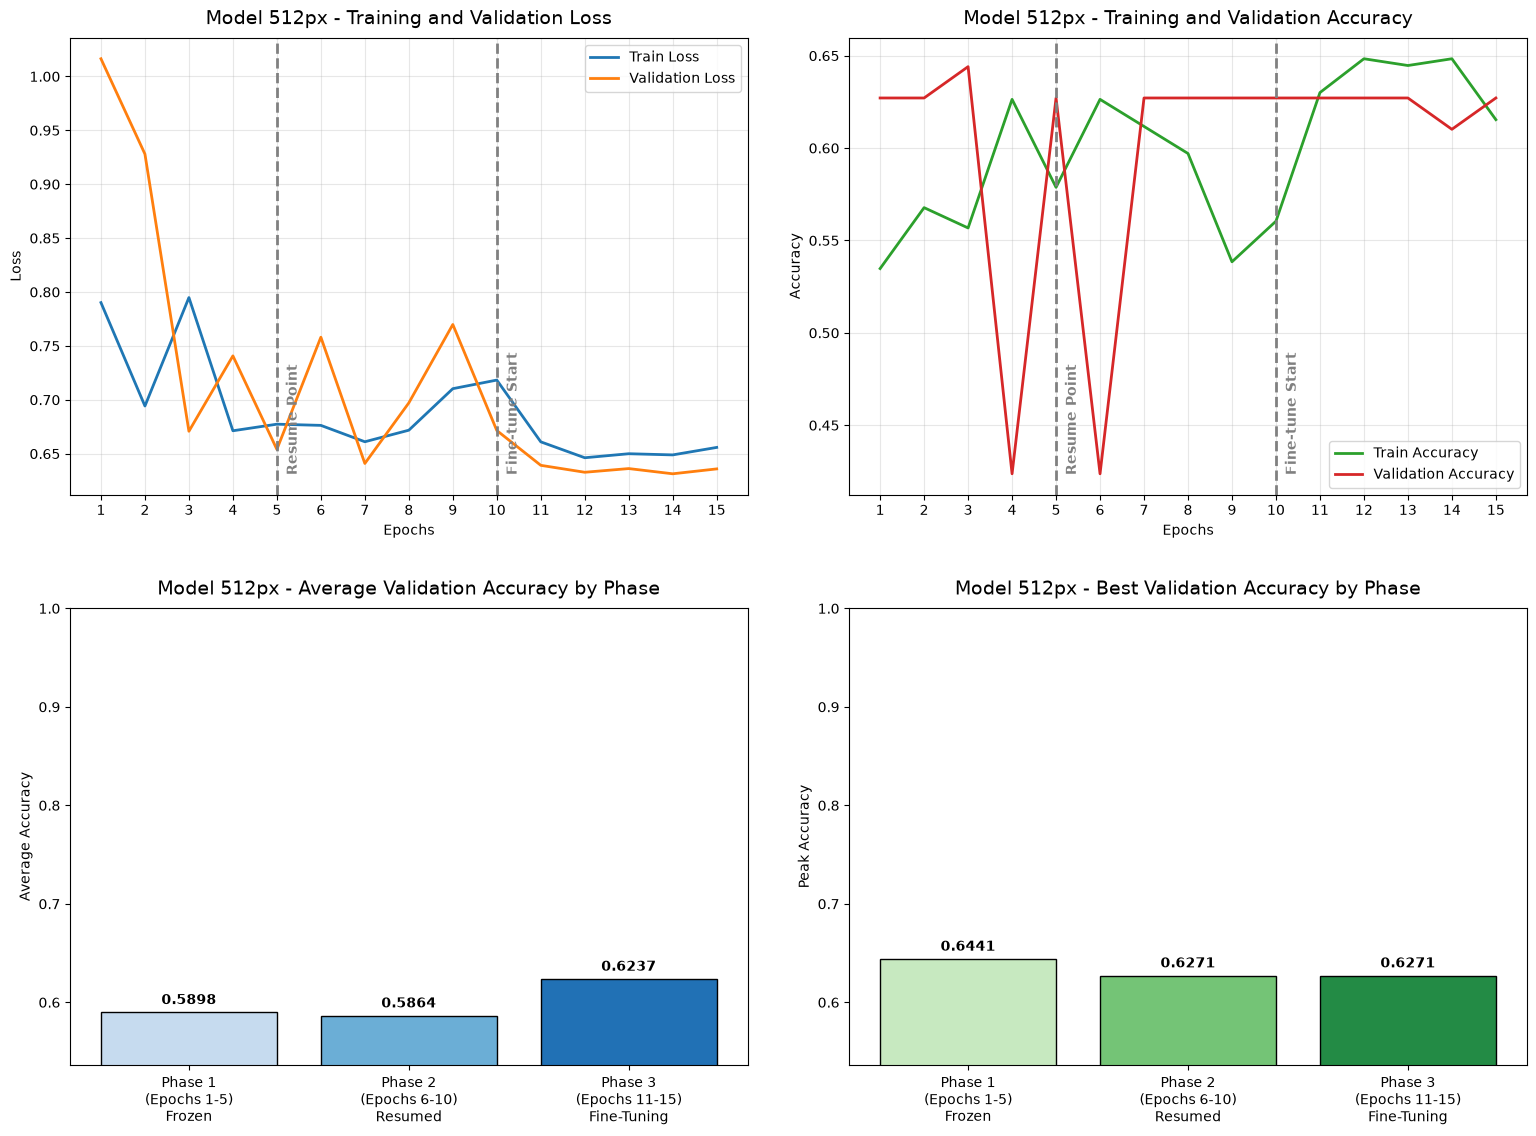


=== Generating Plots for 256px Model ===
Figure saved successfully as 'images/training_history_model_256px.png' with DPI=300.


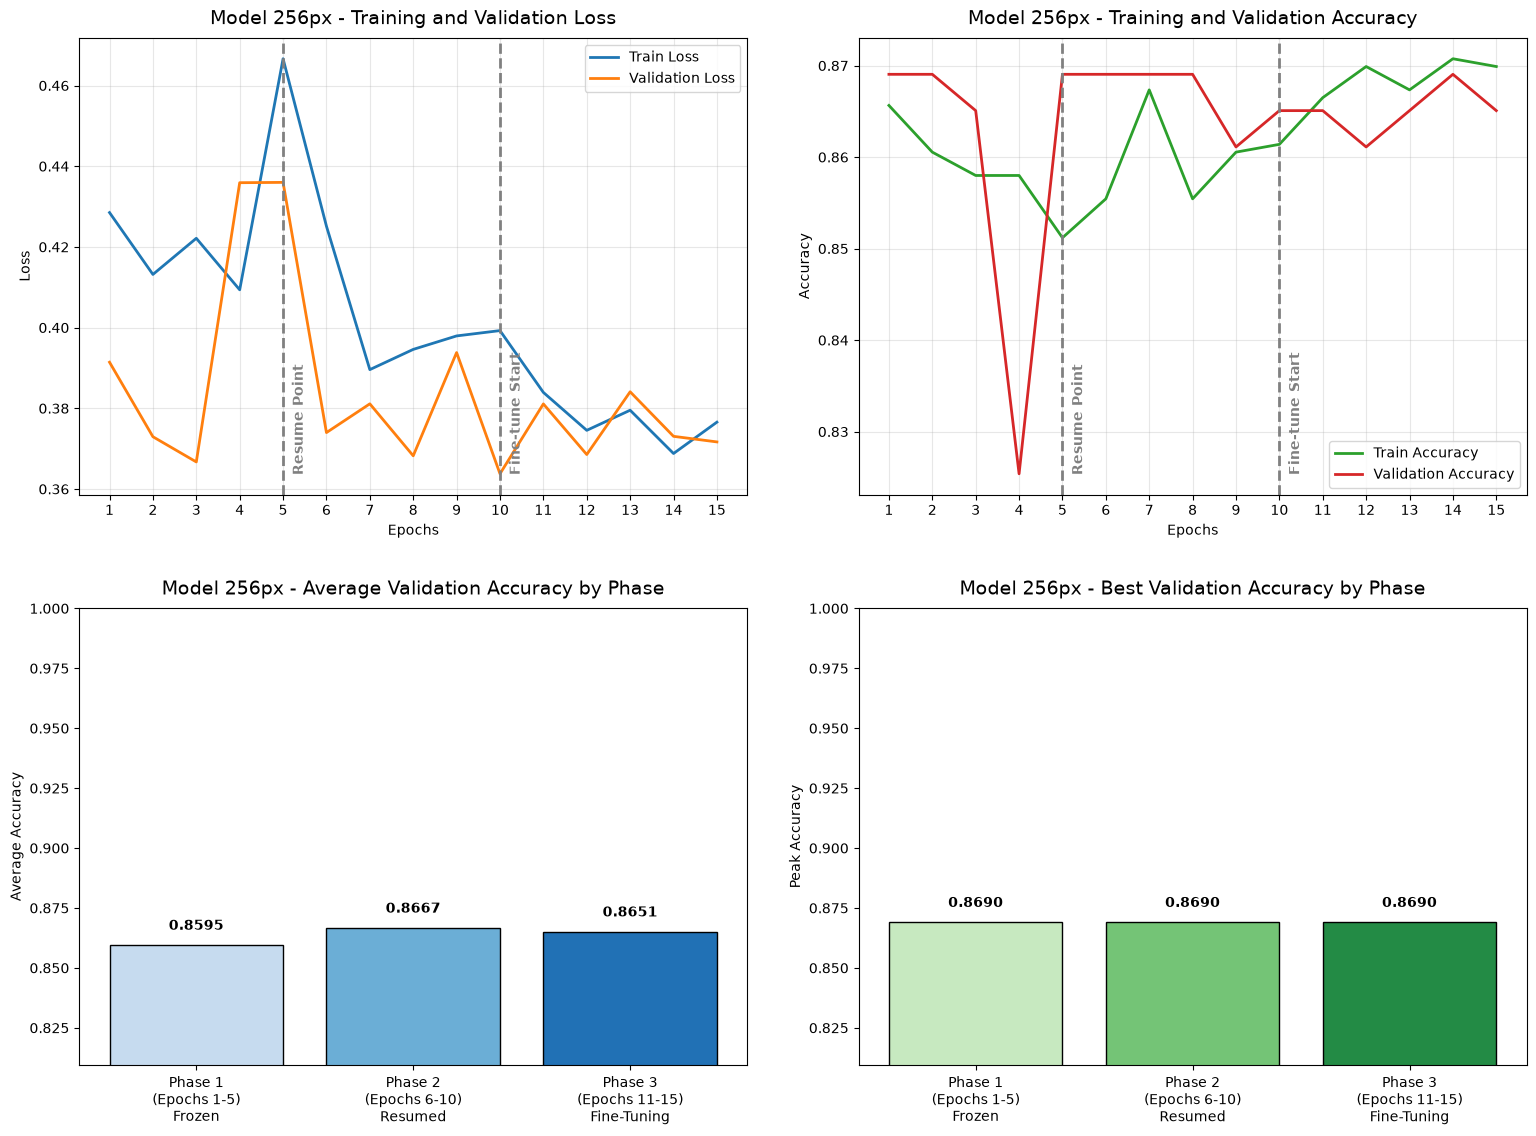

In [44]:
def consolidate_history(h1, h2, h3):
    """Combines histories from all three phases into a single continuous sequence."""
    return {
        'epochs': list(range(1, 16)),
        'train_loss': h1['train_loss'] + h2['train_loss'] + h3['train_loss'],
        'val_loss': h1['val_loss'] + h2['val_loss'] + h3['val_loss'],
        'train_acc': h1['train_acc'] + h2['train_acc'] + h3['train_acc'],
        'val_acc': h1['val_acc'] + h2['val_acc'] + h3['val_acc'],
    }


# Make image directory to save png files
os.makedirs("images", exist_ok=True)


def plot_training_history(history, model_name):
    """Plots the 2x2 training history layout for a given model's history."""
    # Set up the 2x2 figure grid
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    epochs = history['epochs']
    
    # Helper to place text annotations consistently regardless of data scale
    def add_phase_lines(ax):
        # Add vertical lines at phase transition points
        ax.axvline(x=5, color='gray', linestyle='--', linewidth=2)
        ax.axvline(x=10, color='gray', linestyle='--', linewidth=2)
        
        # Use axes transform so y=0.05 is always 5% from the bottom of the graph
        trans = ax.get_xaxis_transform()
        ax.text(5.2, 0.05, 'Resume Point', rotation=90, transform=trans, color='gray', fontweight='bold')
        ax.text(10.2, 0.05, 'Fine-tune Start', rotation=90, transform=trans, color='gray', fontweight='bold')

    # Panel 1 (Top-Left): Loss Curves
    axs[0, 0].plot(epochs, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    axs[0, 0].plot(epochs, history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    add_phase_lines(axs[0, 0])
    axs[0, 0].set_title(f'{model_name} - Training and Validation Loss', fontsize=14, pad=10)
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].set_xticks(epochs) # Show all epoch numbers

    # Panel 2 (Top-Right): Accuracy Curves
    axs[0, 1].plot(epochs, history['train_acc'], label='Train Accuracy', color='#2ca02c', linewidth=2)
    axs[0, 1].plot(epochs, history['val_acc'], label='Validation Accuracy', color='#d62728', linewidth=2)
    add_phase_lines(axs[0, 1])
    axs[0, 1].set_title(f'{model_name} - Training and Validation Accuracy', fontsize=14, pad=10)
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Accuracy')
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].set_xticks(epochs)

    # Data Preparation for Bar Charts
    # Slicing the lists into the 3 distinct phases
    val_p1 = history['val_acc'][:5]   # Epochs 1-5
    val_p2 = history['val_acc'][5:10] # Epochs 6-10
    val_p3 = history['val_acc'][10:]  # Epochs 11-15

    phases = ['Phase 1\n(Epochs 1-5)\nFrozen', 'Phase 2\n(Epochs 6-10)\nResumed', 'Phase 3\n(Epochs 11-15)\nFine-Tuning']
    avgs = [np.mean(val_p1), np.mean(val_p2), np.mean(val_p3)]
    bests = [np.max(val_p1), np.max(val_p2), np.max(val_p3)]

    # Calculate a dynamic y-axis lower limit so the bar differences are highly visible
    y_min = max(0.0, min(min(avgs), min(bests)) - 0.05) 

    # Panel 3 (Bottom-Left): Average Accuracy by Phase
    bars_avg = axs[1, 0].bar(phases, avgs, color=['#c6dbef', '#6baed6', '#2171b5'], edgecolor='black')
    axs[1, 0].set_title(f'{model_name} - Average Validation Accuracy by Phase', fontsize=14, pad=10)
    axs[1, 0].set_ylabel('Average Accuracy')
    axs[1, 0].set_ylim(y_min, 1.0) # Zoom in to show differences

    # Add text labels on top of the bars
    for bar in bars_avg:
        yval = bar.get_height()
        axs[1, 0].text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

    # Panel 4 (Bottom-Right): Best Accuracy by Phase
    bars_best = axs[1, 1].bar(phases, bests, color=['#c7e9c0', '#74c476', '#238b45'], edgecolor='black')
    axs[1, 1].set_title(f'{model_name} - Best Validation Accuracy by Phase', fontsize=14, pad=10)
    axs[1, 1].set_ylabel('Peak Accuracy')
    axs[1, 1].set_ylim(y_min, 1.0)

    # Add text labels on top of the bars
    for bar in bars_best:
        yval = bar.get_height()
        axs[1, 1].text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

    # Final Formatting and Saving
    # Prevent overlapping layout
    plt.tight_layout(pad=3.0)

    # Save the figure
    file_name = f"images/training_history_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    print(f"Figure saved successfully as '{file_name}' with DPI=300.")

    # Display the plot
    plt.show()


# Consolidate and Plot: 512px Model
history_512 = consolidate_history(history_phase1_512, history_phase2_512, history_phase3_512)
print("=== Generating Plots for 512px Model ===")
plot_training_history(history_512, "Model 512px")

# Consolidate and Plot: 256px Model
history_256 = consolidate_history(history_phase1_256, history_phase2_256, history_phase3_256)
print("\n=== Generating Plots for 256px Model ===")
plot_training_history(history_256, "Model 256px")

## Step 6.2: Test Set Evaluation

Loading final best checkpoint for 512px model...
--- Checkpoint Loaded ---
File: checkpoints/final_best_512.pth
Resumed from Epoch: 1
Saved Training Loss: 0.6610
Saved Validation Acc: 0.6271
Model state restored (Optimizer state skipped).


=== Evaluation Results: Model 512px ===
Test Accuracy: 0.6271

--- Classification Report ---
              precision    recall  f1-score   support

  No TNT (0)       0.64      0.97      0.77        38
     TNT (1)       0.00      0.00      0.00        21

    accuracy                           0.63        59
   macro avg       0.32      0.49      0.39        59
weighted avg       0.41      0.63      0.50        59



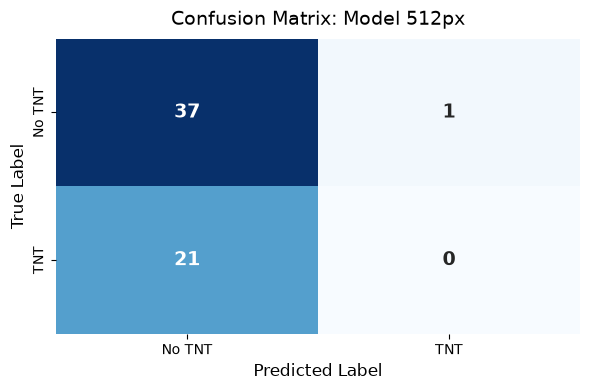


Loading final best checkpoint for 256px model...
--- Checkpoint Loaded ---
File: checkpoints/final_best_256.pth
Resumed from Epoch: 4
Saved Training Loss: 0.3688
Saved Validation Acc: 0.8690
Model state restored (Optimizer state skipped).


=== Evaluation Results: Model 256px ===
Test Accuracy: 0.8730

--- Classification Report ---
              precision    recall  f1-score   support

  No TNT (0)       0.87      1.00      0.93       220
     TNT (1)       0.00      0.00      0.00        32

    accuracy                           0.87       252
   macro avg       0.44      0.50      0.47       252
weighted avg       0.76      0.87      0.81       252



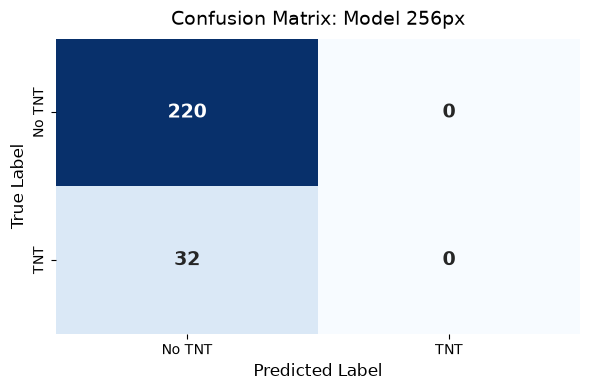

In [45]:
def evaluate_on_test_set(model, dataloader, device):
    """
    Evaluates the model on the provided dataloader and returns true labels and predictions.
    """
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device).float()
            
            # Forward pass
            outputs = model(images).squeeze(-1)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            
            # Store results
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    return np.array(y_true), np.array(y_pred)

def generate_evaluation_report(y_true, y_pred, model_name):
    """
    Prints the classification report and plots the confusion matrix.
    """
    # Calculate Test Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"=== Evaluation Results: {model_name} ===")
    print(f"{'='*50}")
    print(f"Test Accuracy: {acc:.4f}\n")
    
    # Classification Report
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['No TNT (0)', 'TNT (1)']))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No TNT', 'TNT'], 
                yticklabels=['No TNT', 'TNT'],
                cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    
    plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=10)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    
    # Save the confusion matrix plot
    file_name = f"images/confusion_matrix_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()


# Evaluate 512px Model
print("Loading final best checkpoint for 512px model...")
load_checkpoint(filepath="checkpoints/final_best_512.pth", model=model_512, device=device)

y_true_512, y_pred_512 = evaluate_on_test_set(model_512, test_loader_512, device)
generate_evaluation_report(y_true_512, y_pred_512, "Model 512px")

# Evaluate 256px Model
print("\nLoading final best checkpoint for 256px model...")
load_checkpoint(filepath="checkpoints/final_best_256.pth", model=model_256, device=device)

y_true_256, y_pred_256 = evaluate_on_test_set(model_256, test_loader_256, device)
generate_evaluation_report(y_true_256, y_pred_256, "Model 256px")

## Step 6.3: Qualitative Results

=== Generating 4x4 Test Grid for 512px Model ===


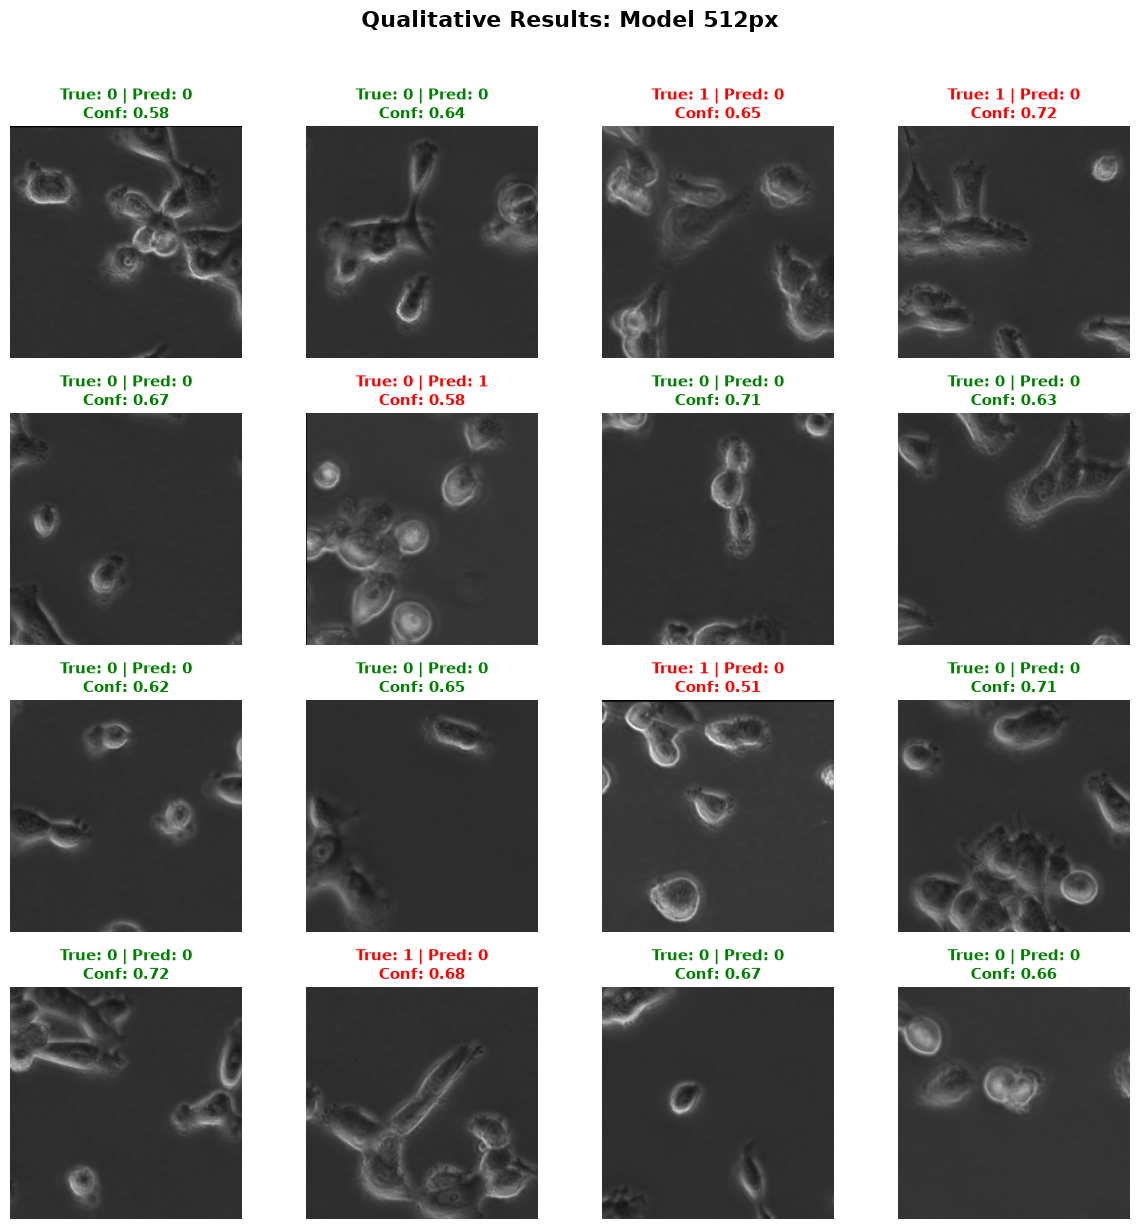


=== Generating 4x4 Test Grid for 256px Model ===


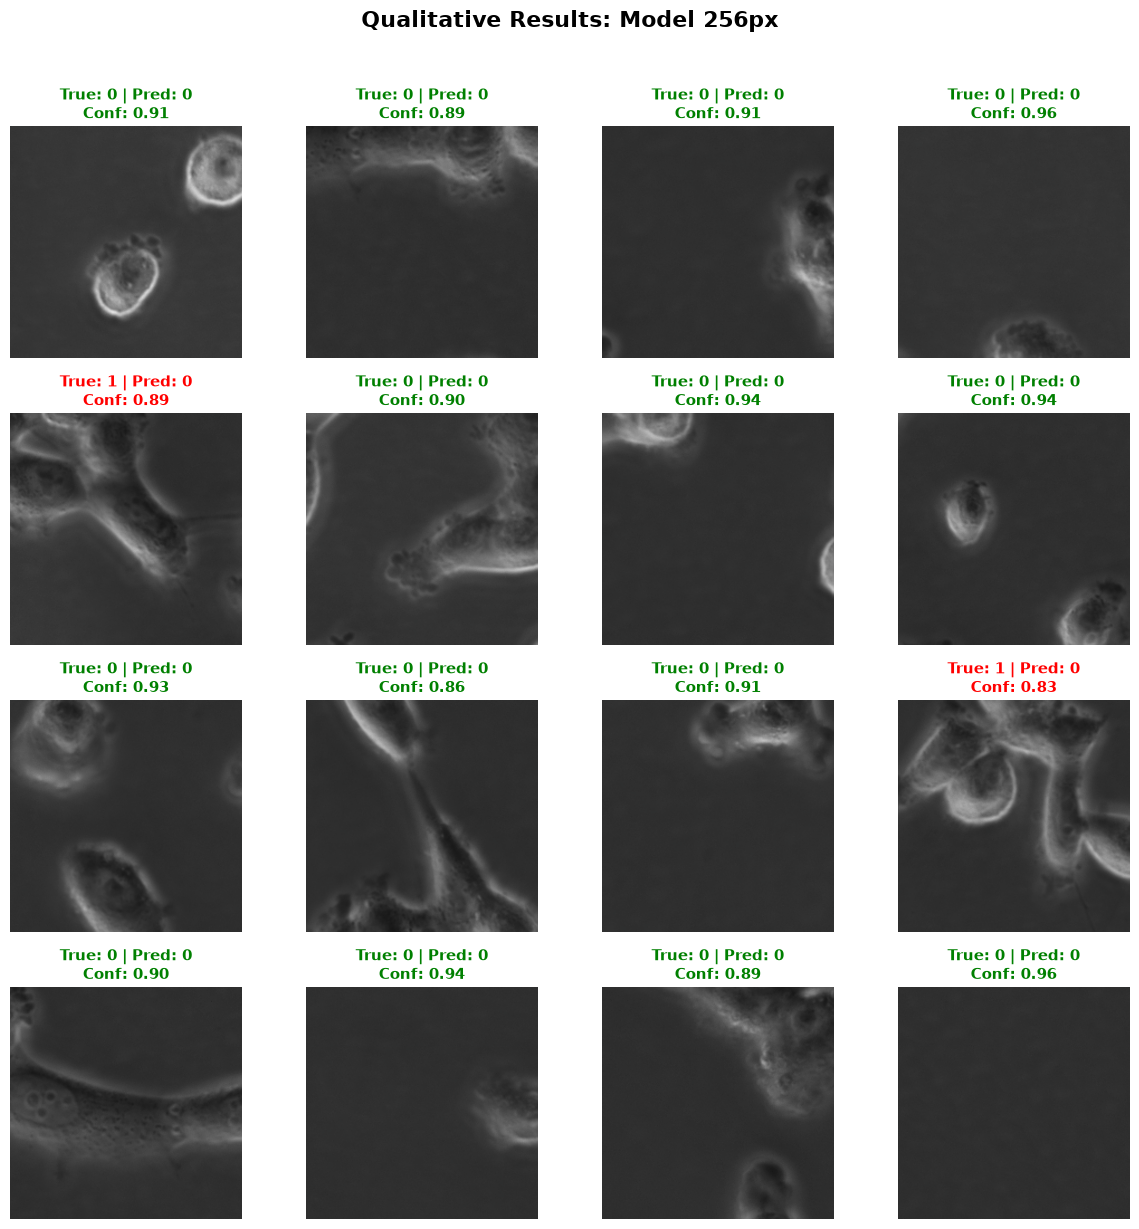

In [46]:
def unnormalize(tensor):
    """
    Reverses the ImageNet normalization applied during the dataset creation
    so the image can be properly displayed by matplotlib.
    """
    # ImageNet mean and std
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    
    # Move to CPU and convert to numpy
    img = tensor.cpu().numpy()
    
    # Un-normalize
    img = img * std + mean
    img = np.clip(img, 0, 1) # Ensure pixel values are within [0, 1]
    
    # Transpose from (C, H, W) to (H, W, C) for plotting
    return np.transpose(img, (1, 2, 0))

def plot_qualitative_grid(model, dataloader, device, model_name):
    """
    Generates a 4x4 grid of test patches displaying True/Predicted labels and confidence.
    """
    model.eval()
    
    # Fetch exactly one batch of test data
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    # We only need 16 images for a 4x4 grid
    images = images[:16]
    labels = labels[:16]
    
    with torch.no_grad():
        img_tensors = images.to(device)
        outputs = model(img_tensors).squeeze(-1)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        
    # Setup the 4x4 plot
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle(f'Qualitative Results: {model_name}', fontsize=16, fontweight='bold', y=1.02)
    
    for idx, ax in enumerate(axes.flat):
        # Prepare image for display
        img_show = unnormalize(images[idx])
        
        # Get label, prediction, and probability
        true_label = int(labels[idx].item())
        pred_label = int(preds[idx].item())
        prob = probs[idx].item()
        
        # Calculate confidence score for the specific predicted class
        confidence = prob if pred_label == 1 else 1.0 - prob
        
        # Determine text color based on prediction accuracy
        text_color = 'green' if true_label == pred_label else 'red'
        
        # Plot the image patch
        ax.imshow(img_show)
        ax.axis('off')
        
        # Set the title with labels and confidence
        title_text = f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2f}"
        ax.set_title(title_text, color=text_color, fontsize=11, fontweight='bold')
        
    plt.tight_layout()
    
    # Save the figure
    file_name = f"images/qualitative_grid_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

# Qualitative Grid for 512px Model
print("=== Generating 4x4 Test Grid for 512px Model ===")
plot_qualitative_grid(model_512, test_loader_512, device, "Model 512px")

# Qualitative Grid for 256px Model
print("\n=== Generating 4x4 Test Grid for 256px Model ===")
plot_qualitative_grid(model_256, test_loader_256, device, "Model 256px")